# TCR-Epitope Binding
***Artificial Intelligence For Science - 4960*** <br>
***Task Four - Traditional AI: SVM, AdaBoost, LightGBM*** <br>
***By: Swaroop Sridhar*** <br>

### Import Libraries
Here we import Python libraries needed for the analysis:
- NumPy and Pandas for data manipulation
- Matplotlib and Seaborn for visualization
- TDC for loading the TCR-Epitope binding dataset
- Scikit-learn libraries for machine learning models (AdaBoost, SVC)
- LightGBM for gradient boosting
- Various metrics for model evaluation

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tdc.multi_pred import TCREpitopeBinding
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix

### Data Loading and Initial Analysis
Here we:
- Load the Weber TCR-Epitope binding dataset
- Analyze sequence lengths for TCR and epitope sequences
- Prepare features and target variables
- Display class distribution and example sequences

The analysis helps understand the characteristics of our input data before processing.

In [33]:
from tdc.multi_pred import TCREpitopeBinding

# Load the Weber dataset
data = TCREpitopeBinding(name='weber')
split = data.get_split()

# Analyze sequence lengths
train_tcr_lengths = [len(seq) for seq in split['train']['tcr']]
train_tcr_full_lengths = [len(seq) for seq in split['train']['tcr_full']]
train_epitope_lengths = [len(seq) for seq in split['train']['epitope_aa']]

print("TCR Sequence Statistics:")
print(f"Max length: {max(train_tcr_lengths)}")
print(f"Min length: {min(train_tcr_lengths)}")
print(f"Mean length: {np.mean(train_tcr_lengths):.2f}")

print("\nFull TCR Sequence Statistics:")
print(f"Max length: {max(train_tcr_full_lengths)}")
print(f"Min length: {min(train_tcr_full_lengths)}")
print(f"Mean length: {np.mean(train_tcr_full_lengths):.2f}")

print("\nEpitope Sequence Statistics:")
print(f"Max length: {max(train_epitope_lengths)}")
print(f"Min length: {min(train_epitope_lengths)}")
print(f"Mean length: {np.mean(train_epitope_lengths):.2f}")

# Prepare features and target
X = pd.DataFrame({
    'tcr_sequence': split['train']['tcr'],
    'tcr_full_sequence': split['train']['tcr_full'],
    'epitope_sequence': split['train']['epitope_aa'],
    'epitope_smiles': split['train']['epitope_smi']
})
y = split['train']['label']

# Display class distribution
print("\nClass Distribution:")
print(y.value_counts(normalize=True))

# Display a few examples
print("\nExample Sequences:")
print("\nTCR sequence example:", X['tcr_sequence'].iloc[0])
print("\nFull TCR sequence example:", X['tcr_full_sequence'].iloc[0])
print("\nEpitope sequence example:", X['epitope_sequence'].iloc[0])
print("\nEpitope SMILES example:", X['epitope_smiles'].iloc[0][:100] + '...')

Found local copy...
Loading...
Done!


TCR Sequence Statistics:
Max length: 33
Min length: 7
Mean length: 14.52

Full TCR Sequence Statistics:
Max length: 127
Min length: 74
Mean length: 110.10

Epitope Sequence Statistics:
Max length: 20
Min length: 8
Mean length: 9.79

Class Distribution:
label
1    0.500545
0    0.499455
Name: proportion, dtype: float64

Example Sequences:

TCR sequence example: CSVWGTGKTYEQYF

Full TCR sequence example: SAVISQKPSRDICQRGTSLTIQCQVDSQVTMMFWYRQQPGQSLTLIATANQGSEATYESGFVIDKFPISRPNLTFSTLTVSNMSPEDSSIYLCSVWGTGKTYEQYFGPGTRLTVT

Epitope sequence example: FLKEKGGL

Epitope SMILES example: CC(C)C[C@H](NC(=O)CNC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(C)...


### Feature Engineering Functions
Here we define two key functions for feature extraction:
1. `create_sequence_features`: Converts amino acid sequences into numerical features by calculating:
   - Sequence length
   - Amino acid frequencies
   - Biochemical properties (hydrophobic, polar, charged, etc.)
2. `create_smiles_features`: Extracts basic features from SMILES strings by counting molecular characteristics

In [34]:
def create_sequence_features(sequence):
    """Convert amino acid sequence to numerical features"""
    # Calculate sequence length
    length = len(sequence)
    
    # Calculate amino acid frequencies
    aa_freq = {}
    for aa in 'ACDEFGHIKLMNPQRSTVWY':
        aa_freq[aa] = sequence.count(aa) / length
    
    # Calculate biochemical properties
    hydrophobic = sum(sequence.count(aa) for aa in 'AILMFWYV') / length
    polar = sum(sequence.count(aa) for aa in 'QNSTC') / length
    charged = sum(sequence.count(aa) for aa in 'RHKDE') / length
    
    # Additional TCR/Epitope specific properties
    aromatic = sum(sequence.count(aa) for aa in 'FWY') / length
    aliphatic = sum(sequence.count(aa) for aa in 'ILV') / length
    
    return [length, hydrophobic, polar, charged, aromatic, aliphatic] + list(aa_freq.values())

def create_smiles_features(smiles):
    """Extract basic features from SMILES string"""
    features = [
        len(smiles),  # Length of SMILES
        smiles.count('('),  # Number of branches
        smiles.count('='),  # Number of double bonds
        smiles.count('#'),  # Number of triple bonds
        smiles.count('['),  # Number of atomic specifications
        sum(c.isupper() for c in smiles),  # Number of atoms
    ]
    return features

### Data Processing and Feature Creation
Here it processes both training and test data by:
- Converting all sequences into numerical features using the previously defined functions
- Combining features from different sources (TCR, epitope, SMILES)
- Scaling the features using StandardScaler
- Preparing the final training and test sets for model training

In [35]:
# Process TCR sequences
tcr_features = np.array([create_sequence_features(seq) for seq in X['tcr_sequence']])
tcr_full_features = np.array([create_sequence_features(seq) for seq in X['tcr_full_sequence']])

# Process epitope sequences and SMILES
epitope_features = np.array([create_sequence_features(seq) for seq in X['epitope_sequence']])
smiles_features = np.array([create_smiles_features(smi) for smi in X['epitope_smiles']])

# Combine all features
X_combined = np.hstack((tcr_features, tcr_full_features, epitope_features, smiles_features))

# Process test data
X_test = pd.DataFrame({
    'tcr_sequence': split['test']['tcr'],
    'tcr_full_sequence': split['test']['tcr_full'],
    'epitope_sequence': split['test']['epitope_aa'],
    'epitope_smiles': split['test']['epitope_smi']
})
y_test = split['test']['label']

# Process test sequences
test_tcr_features = np.array([create_sequence_features(seq) for seq in X_test['tcr_sequence']])
test_tcr_full_features = np.array([create_sequence_features(seq) for seq in X_test['tcr_full_sequence']])
test_epitope_features = np.array([create_sequence_features(seq) for seq in X_test['epitope_sequence']])
test_smiles_features = np.array([create_smiles_features(smi) for smi in X_test['epitope_smiles']])

# Combine test features
X_test_combined = np.hstack((test_tcr_features, test_tcr_full_features, 
                           test_epitope_features, test_smiles_features))

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_combined)
X_test_scaled = scaler.transform(X_test_combined)
y_train = y

### Model Training Framework
Here we define a function `train_and_evaluate_classifier` that:
- Trains a given classifier model
- Generates predictions
- Calculates various performance metrics:
  - Accuracy
  - ROC curve and AUC
  - Precision-Recall curve and AUC

This function will be used to evaluate multiple models consistently.

In [36]:
# Block 5: Model Training Function
def train_and_evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name=''):
    """
    Train a classifier and evaluate its performance
    """
    # Train model
    if model_name == 'lightgbm':
        # Modified LightGBM fitting parameters
        model.fit(X_train, y_train,
                 eval_metric='logloss',
                 eval_set=[(X_test, y_test)],
                 callbacks=[lgb.callback.early_stopping(stopping_rounds=10)])
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    return {
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall
    }

### Model Training and Evaluation
Here we initialize and train three different models:
- Support Vector Machine (SVM)
- AdaBoost
- LightGBM

Also evaluates each model and prints comprehensive performance metrics including:
- Accuracy
- ROC AUC
- PR AUC
- Detailed classification reports

In [37]:
# Initialize models
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1  # Added to suppress warnings
)

# Train and evaluate models
svm_results = train_and_evaluate_classifier(svm_model, X_train_scaled, X_test_scaled, y_train, y_test)
ada_results = train_and_evaluate_classifier(ada_model, X_train_scaled, X_test_scaled, y_train, y_test)
lgb_results = train_and_evaluate_classifier(lgb_model, X_train_scaled, X_test_scaled, y_train, y_test, 'lightgbm')

# Print results
for name, results in [('SVM', svm_results), 
                     ('AdaBoost', ada_results), 
                     ('LightGBM', lgb_results)]:
    print(f"\n{name} Results:")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"ROC AUC: {results['roc_auc']:.4f}")
    print(f"PR AUC: {results['pr_auc']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, results['predictions']))

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.552732

SVM Results:
Accuracy: 0.7266
ROC AUC: 0.7849
PR AUC: 0.7630

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      4756
           1       0.72      0.73      0.73      4680

    accuracy                           0.73      9436
   macro avg       0.73      0.73      0.73      9436
weighted avg       0.73      0.73      0.73      9436


AdaBoost Results:
Accuracy: 0.6024
ROC AUC: 0.6486
PR AUC: 0.6319

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.62      0.61      4756
           1       0.60      0.59      0.60      4680

    accuracy                           0.60      9436
   macro avg       0.60      0.60      0.60      9436
weighted avg       0.60      0.60      0.60      9436


LightGBM Results:


### Visualization of Model Performance
Here we create three types of visualizations to compare model performance:
1. ROC curves showing the trade-off between true positive and false positive rates
2. Precision-Recall curves displaying the trade-off between precision and recall
3. Confusion matrices showing the detailed breakdown of predictions for each model
These visualizations help in understanding how each model performs across different metrics.

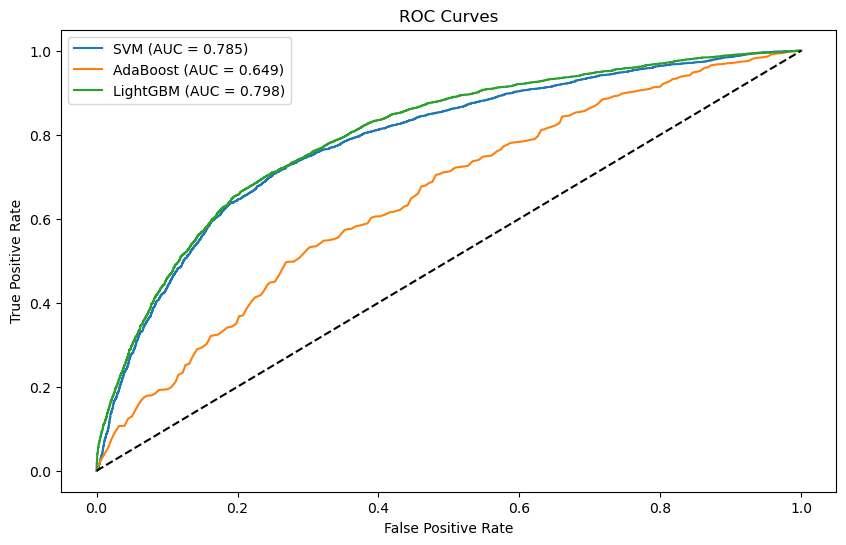

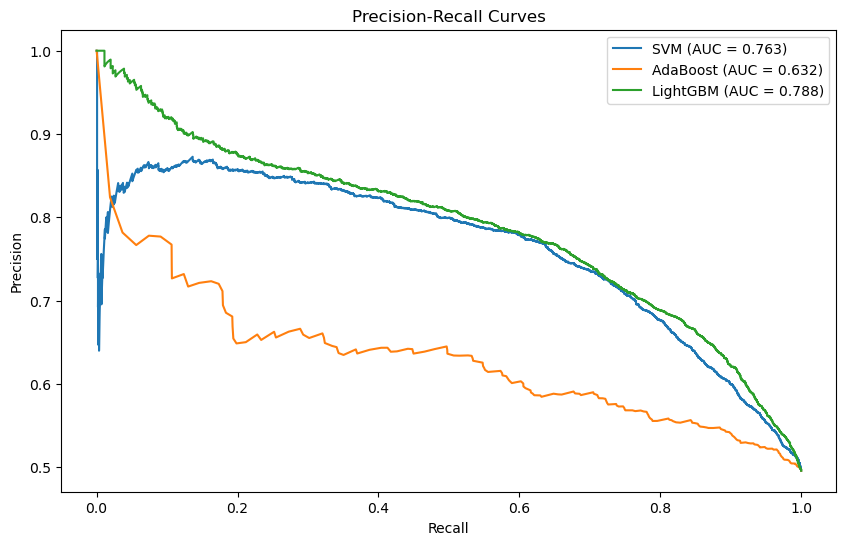

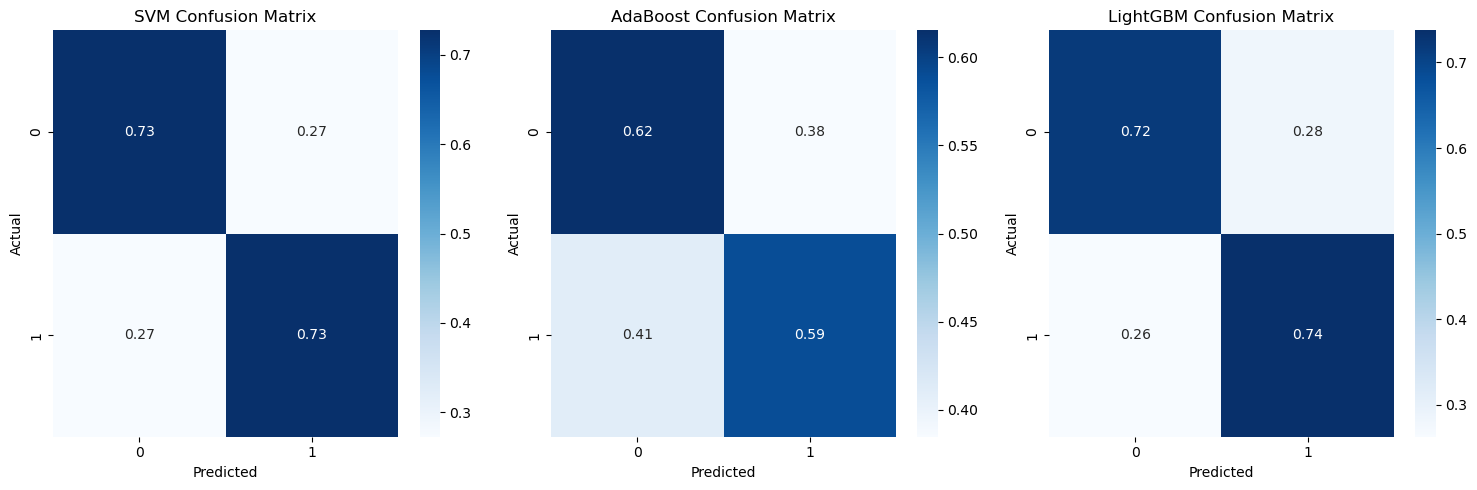

In [38]:
plt.figure(figsize=(10, 6))
for name, results in [('SVM', svm_results), 
                     ('AdaBoost', ada_results), 
                     ('LightGBM', lgb_results)]:
    plt.plot(results['fpr'], results['tpr'], 
             label=f'{name} (AUC = {results["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(10, 6))
for name, results in [('SVM', svm_results), 
                     ('AdaBoost', ada_results), 
                     ('LightGBM', lgb_results)]:
    plt.plot(results['recall'], results['precision'], 
             label=f'{name} (AUC = {results["pr_auc"]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, results) in zip(axes, [('SVM', svm_results), 
                                    ('AdaBoost', ada_results), 
                                    ('LightGBM', lgb_results)]):
    sns.heatmap(confusion_matrix(y_test, results['predictions'], normalize='true'),
                annot=True, fmt='.2f', ax=ax, cmap='Blues')
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Feature Importance Analysis
Finally, we analyze and visualize feature importance using:
- LightGBM's built-in feature importance
- AdaBoost's feature importance
- Groups features into categories to understand which types of features are most influential

This helps identify which features contribute most to the model's predictions.

Shape of X_train_scaled: (33028, 84)
Number of LightGBM importance values: 84
Indices min and max: 26 83


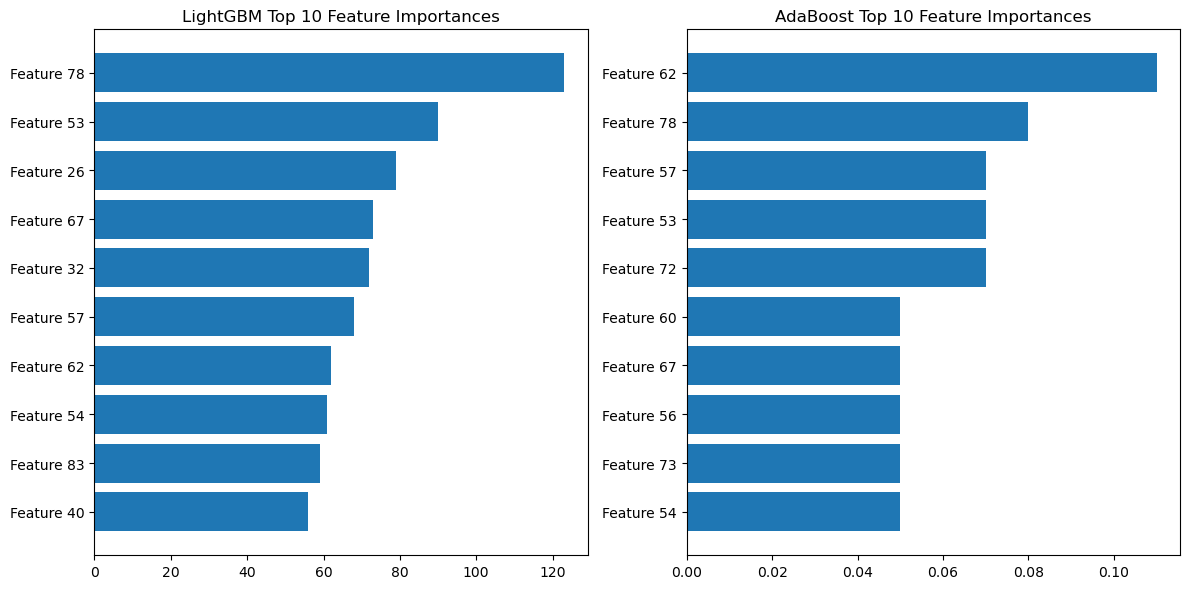

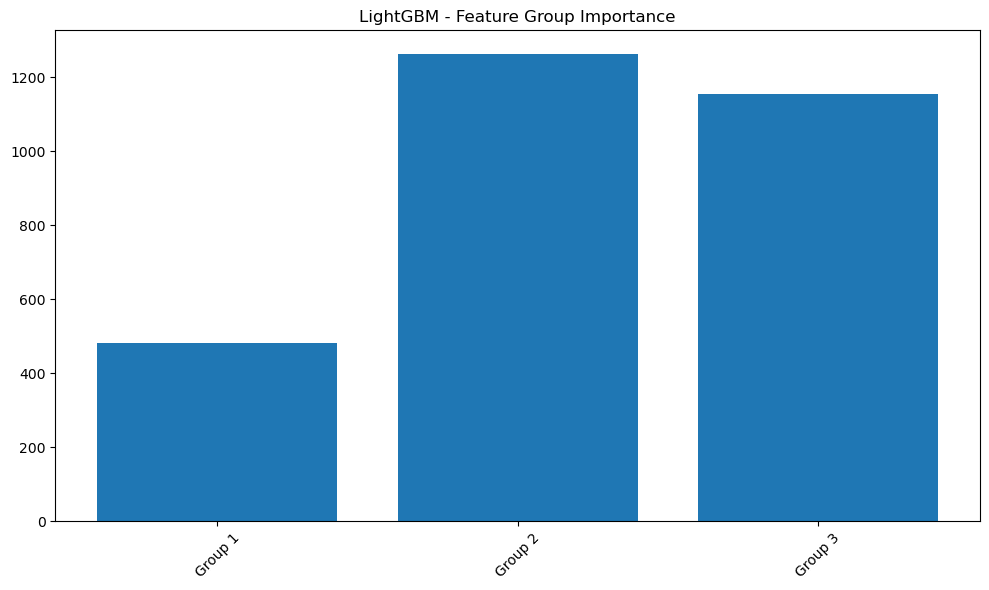

In [45]:
# First, let's see what we're working with
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Number of LightGBM importance values:", len(lgb_importances))
print("Indices min and max:", min(indices), max(indices))

# Create feature names based on our actual data dimensions
feature_names = [f'Feature_{i}' for i in range(X_train_scaled.shape[1])]

# Now let's try the visualization
plt.figure(figsize=(12, 6))

# LightGBM feature importance
lgb_importances = lgb_model.feature_importances_
num_features = min(len(lgb_importances), 10)  # Reduced to top 10 features to be safe
indices = np.argsort(lgb_importances)[-num_features:]

plt.subplot(1, 2, 1)
plt.title('LightGBM Top 10 Feature Importances')
plt.barh(range(num_features), lgb_importances[indices])
plt.yticks(range(num_features), [f'Feature {i}' for i in indices])

# AdaBoost feature importance
ada_importances = ada_model.feature_importances_
indices = np.argsort(ada_importances)[-num_features:]
plt.subplot(1, 2, 2)
plt.title('AdaBoost Top 10 Feature Importances')
plt.barh(range(num_features), ada_importances[indices])
plt.yticks(range(num_features), [f'Feature {i}' for i in indices])

plt.tight_layout()
plt.show()

# Simpler feature type importance visualization
plt.figure(figsize=(10, 6))
feature_groups = np.array_split(range(len(lgb_importances)), 3)
feature_type_importance = {
    'Group 1': np.sum(lgb_importances[feature_groups[0]]),
    'Group 2': np.sum(lgb_importances[feature_groups[1]]),
    'Group 3': np.sum(lgb_importances[feature_groups[2]])
}

plt.bar(feature_type_importance.keys(), feature_type_importance.values())
plt.title('LightGBM - Feature Group Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()